# Importação das bibliotecas

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import time

# Tratamento dos dados

In [4]:
csv_falsos = pd.read_csv('Fake.csv')
csv_verdadeiros = pd.read_csv('True.csv')

In [5]:
csv_falsos.info()
csv_falsos.describe()
csv_falsos.duplicated().sum()
csv_falsos = csv_falsos.drop_duplicates()
csv_falsos = csv_falsos.drop_duplicates(subset=['title', 'text'], keep='first')
csv_falsos = csv_falsos.drop_duplicates(subset=['title'], keep='first')
csv_falsos = csv_falsos.drop_duplicates(subset=['text'], keep='first')
csv_falsos.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
dtypes: object(4)
memory usage: 733.9+ KB


,title,text,subject,date
count,17450,17450,17450,17450
unique,17450,17450,5,1681
top,A Troubled King: Chicago’s Rahm Emanuel Desper...,21st Century Wire says It s not that far away....,News,"May 26, 2016"
freq,1,1,9049,35


In [6]:
csv_verdadeiros.info()
csv_verdadeiros.describe()
csv_verdadeiros.duplicated().sum()
csv_verdadeiros = csv_verdadeiros.drop_duplicates()
csv_verdadeiros = csv_verdadeiros.drop_duplicates(subset=['title', 'text'], keep='first')

# removendo duplicadas que tem titulo e texto igual e mantendo apenas a primeira
csv_verdadeiros = csv_verdadeiros.drop_duplicates(subset=['title'], keep='first')
csv_verdadeiros = csv_verdadeiros.drop_duplicates(subset=['text'], keep='first')
csv_verdadeiros.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    21417 non-null  object
 1   text     21417 non-null  object
 2   subject  21417 non-null  object
 3   date     21417 non-null  object
dtypes: object(4)
memory usage: 669.4+ KB


,title,text,subject,date
count,20821,20821,20821,20821
unique,20821,20821,2,716
top,Indonesia to buy $1.14 billion worth of Russia...,JAKARTA (Reuters) - Indonesia will buy 11 Sukh...,politicsNews,"December 6, 2017"
freq,1,1,11147,165


# Pré-processamento de texto

In [7]:
import re
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

#baixando as stopwords
nltk.download('stopwords')

def limpar_texto(texto):
    texto = texto.lower()  # tudo em minúsculo
    texto = re.sub(r'\d+', '', texto)  # remove números
    texto = re.sub(r'[^\w\s]', '', texto)  # remove pontuação
    texto = texto.strip()  # remove espaços antes e depois
    return texto

#aplicando a limpeza nos datasets
csv_falsos['text_limpo'] = csv_falsos['text'].apply(limpar_texto)
csv_verdadeiros['text_limpo'] = csv_verdadeiros['text'].apply(limpar_texto)

csv_falsos['label'] = 0
csv_verdadeiros['label'] = 1

noticias = pd.concat([csv_falsos, csv_verdadeiros], ignore_index=True)

# Ver primeiras linhas
noticias.head()

noticias.info()

stop_words = set(stopwords.words('english'))

def remover_stopwords(texto):
    palavras = texto.split()
    palavras_filtradas = [p for p in palavras if p not in stop_words]
    return ' '.join(palavras_filtradas)

noticias['text_limpo'] = noticias['text_limpo'].apply(remover_stopwords)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38271 entries, 0 to 38270
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   title       38271 non-null  object
 1   text        38271 non-null  object
 2   subject     38271 non-null  object
 3   date        38271 non-null  object
 4   text_limpo  38271 non-null  object
 5   label       38271 non-null  int64 
dtypes: int64(1), object(5)
memory usage: 1.8+ MB


In [8]:
vetorizado = TfidfVectorizer(max_features=1500)
X = vetorizado.fit_transform(noticias['text_limpo'])
y = noticias['label']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) # 20% para treino e 80% para teste

# Algoritmo 1- Naive Bayes

In [9]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report

start = time.time()
nb = MultinomialNB()
nb.fit(X_train, y_train)
end = time.time()

y_pred_nb = nb.predict(X_test)
print("Resultados - Naive Bayes:")
print(classification_report(y_test, y_pred_nb))
print("Tempo de execução:", round(end - start, 2), "s")

Resultados - Naive Bayes:
              precision    recall  f1-score   support

           0       0.94      0.91      0.93      3490
           1       0.93      0.95      0.94      4165

    accuracy                           0.94      7655
   macro avg       0.94      0.93      0.94      7655
weighted avg       0.94      0.94      0.94      7655

Tempo de execução: 0.03 s


# Algoritmo 2- Random Forest

In [31]:
from sklearn.ensemble import RandomForestClassifier

start = time.time()
rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf.fit(X_train, y_train)
end = time.time()

y_pred_rf = rf.predict(X_test)
print("Resultados - Random Forest:")
print(classification_report(y_test, y_pred_rf))
print("Tempo de execução:", round(end - start, 2), "s")

Resultados - Random Forest:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      3490
           1       0.98      1.00      0.99      4165

    accuracy                           0.99      7655
   macro avg       0.99      0.99      0.99      7655
weighted avg       0.99      0.99      0.99      7655

Tempo de execução: 14.48 s


# Algoritmo 3- Logistic Regression

In [30]:
from sklearn.linear_model import LogisticRegression

start = time.time()
lr = LogisticRegression(C=1, penalty='l1', solver='liblinear', max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
end = time.time()

y_pred_lr = lr.predict(X_test)

print("Resultados - Logistic Regression:")
print(classification_report(y_test, y_pred_lr))
print("Tempo de execução:", round(end - start, 2), "s")

Resultados - Logistic Regression:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      3490
           1       0.99      1.00      1.00      4165

    accuracy                           0.99      7655
   macro avg       1.00      0.99      0.99      7655
weighted avg       0.99      0.99      0.99      7655

Tempo de execução: 0.95 s


# Algoritmo 4- SVM

In [12]:
from sklearn.svm import LinearSVC

start = time.time()
svm = LinearSVC()
svm.fit(X_train, y_train)
end = time.time()

y_pred_svm = svm.predict(X_test)

print("Resultados - SVM:")
print(classification_report(y_test, y_pred_svm))
print("Tempo de execução:", round(end - start, 2), "s")

Resultados - SVM:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      3490
           1       0.99      1.00      0.99      4165

    accuracy                           0.99      7655
   macro avg       0.99      0.99      0.99      7655
weighted avg       0.99      0.99      0.99      7655

Tempo de execução: 0.66 s


#Algoritmo 5- KNN

In [13]:
from sklearn.neighbors import KNeighborsClassifier

start = time.time()
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
end = time.time()

y_pred_knn = knn.predict(X_test)

print("Resultados - KNN:")
print(classification_report(y_test, y_pred_knn))
print("Tempo de execução:", round(end - start, 2), "s")

Resultados - KNN:
              precision    recall  f1-score   support

           0       0.61      0.95      0.74      3490
           1       0.92      0.50      0.65      4165

    accuracy                           0.70      7655
   macro avg       0.77      0.72      0.70      7655
weighted avg       0.78      0.70      0.69      7655

Tempo de execução: 0.03 s


# Validação cruzada SVM

In [14]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(svm, X, y, cv=5)
print(scores.mean())

0.987797438428219


# Análise dos resultados

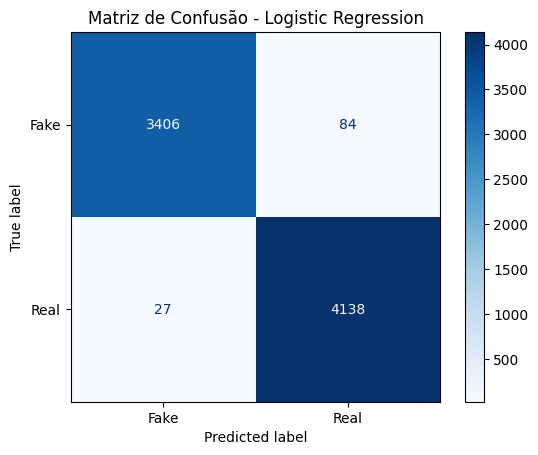

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_lr = confusion_matrix(y_test, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=["Fake", "Real"])
disp_lr.plot(cmap='Blues')
plt.title("Matriz de Confusão - Logistic Regression")
plt.show()

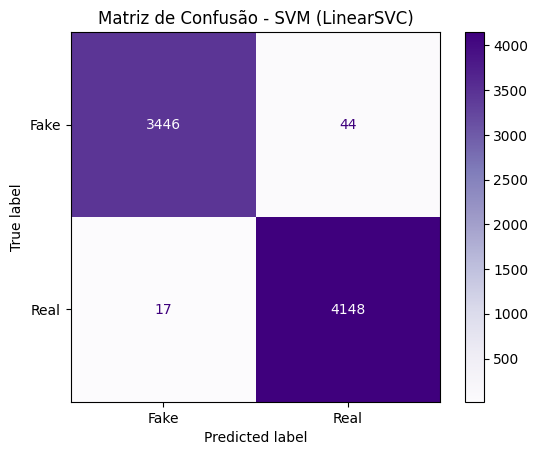

In [16]:
cm_svm = confusion_matrix(y_test, y_pred_svm)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=["Fake", "Real"])
disp_svm.plot(cmap='Purples')
plt.title("Matriz de Confusão - SVM (LinearSVC)")
plt.show()

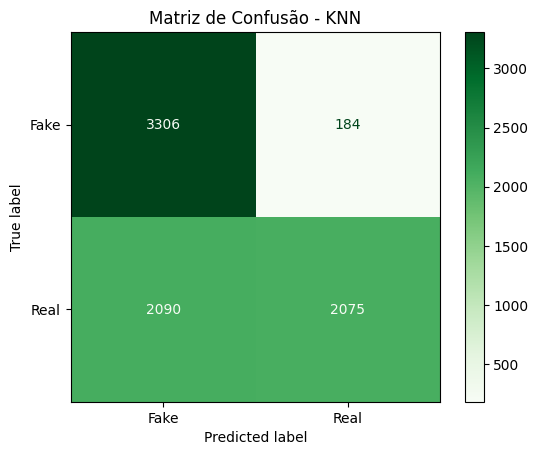

In [17]:
cm_knn = confusion_matrix(y_test, y_pred_knn)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=["Fake", "Real"])
disp_knn.plot(cmap='Greens')
plt.title("Matriz de Confusão - KNN")
plt.show()

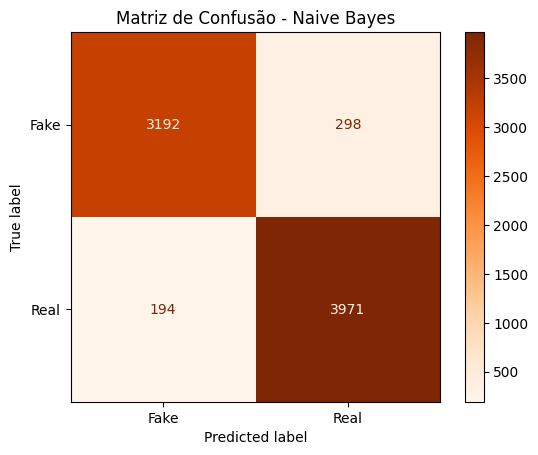

In [18]:
cm_nb = confusion_matrix(y_test, y_pred_nb)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=["Fake", "Real"])
disp_nb.plot(cmap='Oranges')
plt.title("Matriz de Confusão - Naive Bayes")
plt.show()

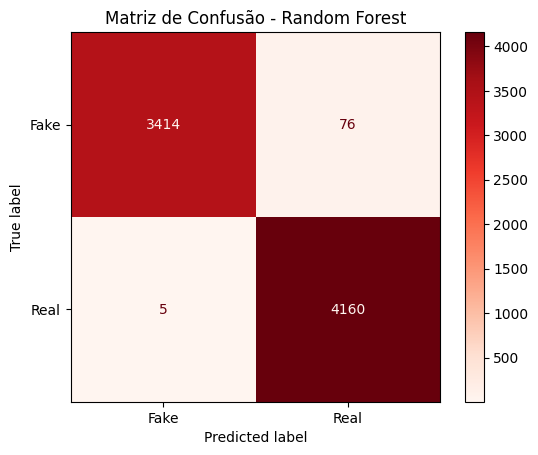

In [19]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["Fake", "Real"])
disp_rf.plot(cmap='Reds')
plt.title("Matriz de Confusão - Random Forest")
plt.show()

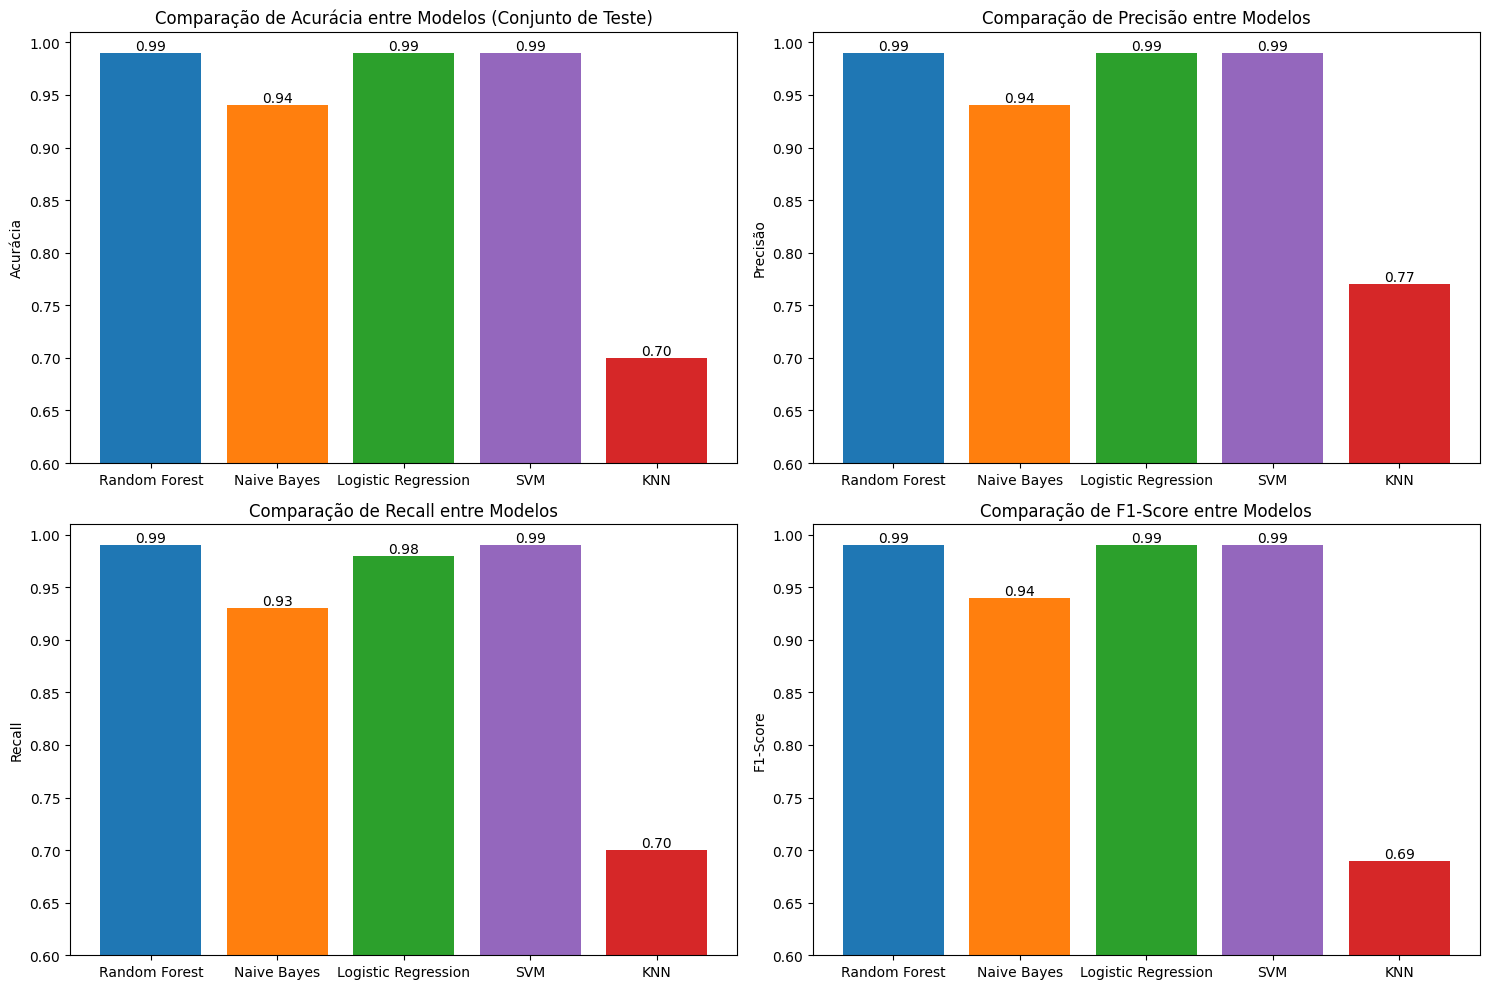

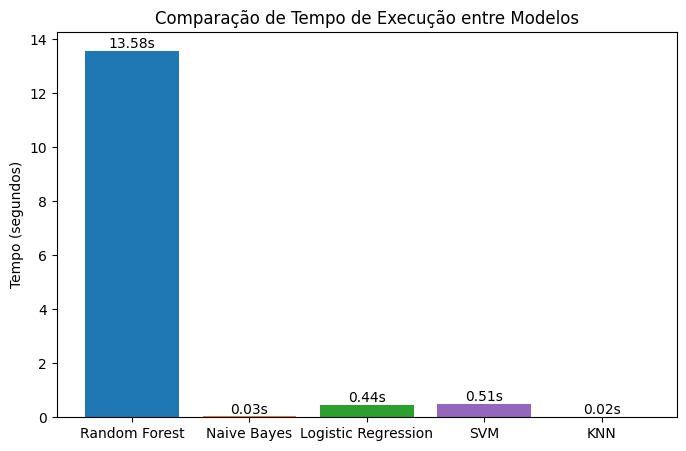

In [20]:
import matplotlib.pyplot as plt

modelos = ['Random Forest', 'Naive Bayes', 'Logistic Regression', 'SVM', 'KNN']

acuracia = [0.99, 0.94, 0.99, 0.99, 0.70]
precisao = [0.99, 0.94, 0.99, 0.99, 0.77]
recall = [0.99, 0.93, 0.98, 0.99, 0.70]
f1_score = [0.99, 0.94, 0.99, 0.99, 0.69]
tempo_execucao = [13.58, 0.03, 0.44, 0.51, 0.02]

cores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#d62728']

plt.figure(figsize=(15, 10))

# Gráfico 1 - Acurácia
plt.subplot(2, 2, 1)
bars = plt.bar(modelos, acuracia, color=cores)
plt.title('Comparação de Acurácia entre Modelos (Conjunto de Teste)')
plt.ylabel('Acurácia')
plt.ylim(0.6, 1.01)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height, f'{height:.2f}', ha='center', va='bottom')

# Gráfico 2 - Precisão
plt.subplot(2, 2, 2)
bars = plt.bar(modelos, precisao, color=cores)
plt.title('Comparação de Precisão entre Modelos')
plt.ylabel('Precisão')
plt.ylim(0.6, 1.01)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height, f'{height:.2f}', ha='center', va='bottom')

# Gráfico 3 - Recall
plt.subplot(2, 2, 3)
bars = plt.bar(modelos, recall, color=cores)
plt.title('Comparação de Recall entre Modelos')
plt.ylabel('Recall')
plt.ylim(0.6, 1.01)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height, f'{height:.2f}', ha='center', va='bottom')

# Gráfico 4 - F1-Score
plt.subplot(2, 2, 4)
bars = plt.bar(modelos, f1_score, color=cores)
plt.title('Comparação de F1-Score entre Modelos')
plt.ylabel('F1-Score')
plt.ylim(0.6, 1.01)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height, f'{height:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Gráfico 5 - Tempo de Execução
plt.figure(figsize=(8, 5))
bars = plt.bar(modelos, tempo_execucao, color=cores)
plt.title('Comparação de Tempo de Execução entre Modelos')
plt.ylabel('Tempo (segundos)')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height, f'{height:.2f}s', ha='center', va='bottom')
plt.show()
